In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
q = 1.6e-19 # C
m = 1.67e-27 # kg
radius = 0.05 # m
gap = 0.005 # m
deltaV = 5000 # V
B_mag = 1.0 # T
dt = 1e-11 # s

In [7]:
x = np.array([0.0,0.0,0.0])
v = np.array([0.0,0.0,0.0])
p = m * v
E0_mag = deltaV / gap
omega = (q / m) * B_mag
omega_factor = 1.00
B = np.array([0.0,0.0,B_mag])
t = 0

x_list, y_list, t_list, KE_list = [], [], [], []

print("Setup complete. Constants initialized.")

Setup complete. Constants initialized.


In [8]:
while np.linalg.norm(x) < radius:

  E = np.array([E0_mag*np.cos(omega_factor*omega*t),0.0,0.0])

  if (np.abs(x[0]) < gap):
    FE = q*E
  else:
    FE = np.array([0.0,0.0,0.0])

  FB = q * np.cross(v, B)

  Fnet = FE + FB

  p += Fnet * dt
  v = p / m
  vmag = np.linalg.norm(v)
  KE = 0.5 * m * vmag * vmag
  x += v * dt
  t += dt

  x_list.append(-x[0]) # flip x values to match convention in PDF
  y_list.append(x[1])
  t_list.append(t)
  KE_list.append(KE)

print(f"Simulation finished! Final kinetic energy: {KE:.2e} J")
print(f"Final kinetic energy in eV: {(KE/q):.2f} eV")

Simulation finished! Final kinetic energy: 1.58e-14 J
Final kinetic energy in eV: 98537.92 eV


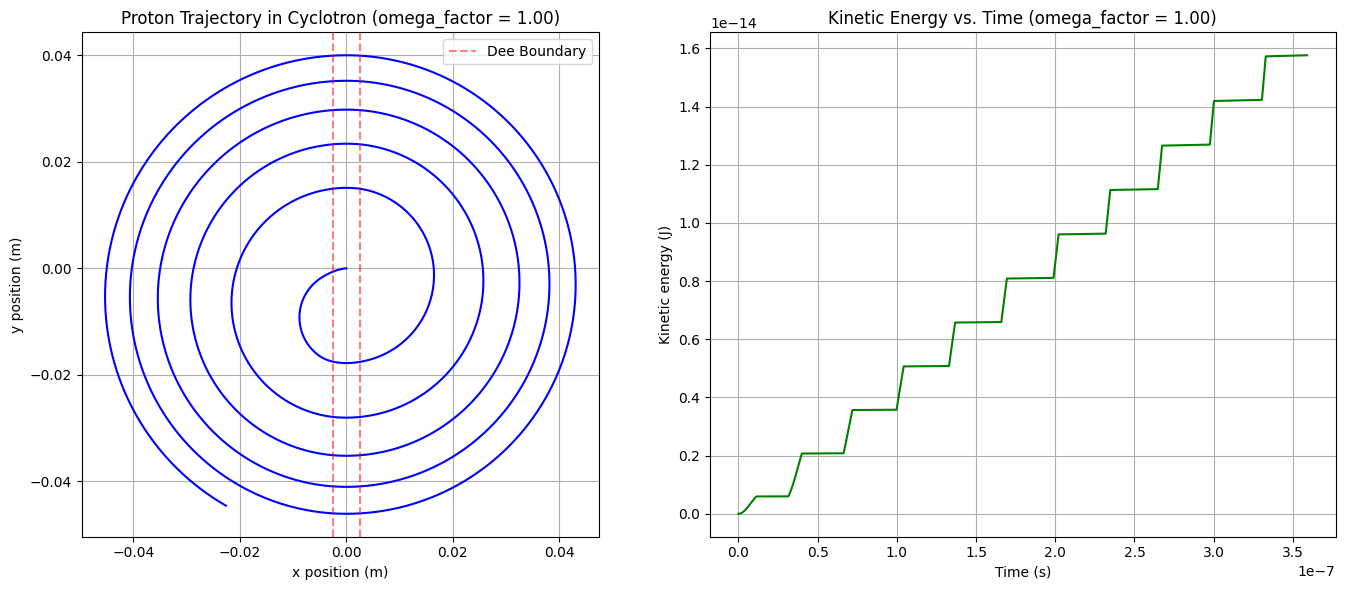

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,6))

ax1.plot(x_list,y_list, color='b')
ax1.set_title(f"Proton Trajectory in Cyclotron (omega_factor = {omega_factor:.2f})")
ax1.set_xlabel("x position (m)")
ax1.set_ylabel("y position (m)")
ax1.axvline(x=gap/2, color='r', linestyle='--', alpha=0.5, label='Dee Boundary')
ax1.axvline(x=-gap/2, color='r', linestyle='--', alpha=0.5)
ax1.set_aspect('equal')
ax1.grid(True)
ax1.legend()

ax2.plot(t_list, KE_list, color='g')
ax2.set_title(f"Kinetic Energy vs. Time (omega_factor = {omega_factor:.2f})")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Kinetic energy (J)")
ax2.grid(True)

plt.tight_layout()
plt.show()